# 第四次作业：卷积神经网络识别 Fashion-MNIST

本 Notebook 根据课件 **第 6 章 6.3“卷积神经网络识别 Fashion-MNIST”** 完成，主要内容包括：

1. 导入 Fashion-MNIST 数据集，并观察一个 batch 的图像。
2. 搭建一个类似 LeNet 思想的卷积神经网络：卷积层、ReLU、平均池化层、全连接层和输出层。
3. 使用训练集训练模型，并用验证集选择效果最好的参数。
4. 在测试集上进行预测，计算整体准确率、每一类准确率，并绘制混淆矩阵。
5. 展示部分预测样例，解释模型哪些类别容易混淆。

> 第一次运行会自动下载 Fashion-MNIST 数据集。


## 1. 导入所需库

这里使用 PyTorch 完成神经网络的搭建与训练，使用 `torchvision.datasets.FashionMNIST` 读取数据集。

关键库说明：

- `torch`：张量计算、自动求导、模型训练。
- `torch.nn`：神经网络层，例如卷积层、池化层、全连接层。
- `torchvision`：常用视觉数据集和图像预处理工具。
- `matplotlib`：显示样本图片、训练曲线和混淆矩阵。


In [16]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# 让实验尽量可复现。
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Windows 下 Jupyter 使用 DataLoader 多进程时容易出现兼容问题，因此设置 num_workers=0。
BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_EPOCHS = 25       # 课件演示设为 25。
LEARNING_RATE = 1e-3

DATA_DIR = Path("./data")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备：{DEVICE}")

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False


使用设备：cuda


## 2. 数据集导入与 DataLoader 构建

Fashion-MNIST 是一个 10 分类灰度图像数据集，每张图像大小为 `28 x 28`。它比手写数字 MNIST 更接近真实服装图像分类任务。

`ToTensor()` 会把 PIL 图像转换成形状为 `[通道数, 高, 宽]` 的张量，并把像素值从 `0~255` 缩放到 `0~1`。

这里把官方训练集 `60000` 张图片再划分为：

- 训练集：`50000` 张，用于更新模型参数。
- 验证集：`10000` 张，用于每轮训练后评估模型并保存最佳参数。
- 测试集：官方测试集 `10000` 张，只在最后评估泛化能力。


In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    transform=transform,
    download=True,
)

test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    transform=transform,
    download=True,
)

train_size = 50_000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

class_names = full_train_dataset.classes

print(f"训练集样本数：{len(train_dataset)}")
print(f"验证集样本数：{len(val_dataset)}")
print(f"测试集样本数：{len(test_dataset)}")
print(f"训练集 batch 数量：{len(train_loader)}")
print(f"类别标签：{class_names}")


训练集样本数：50000
验证集样本数：10000
测试集样本数：10000
训练集 batch 数量：782
类别标签：['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. 查看一个 batch 的图像

训练前先可视化一组样本，确认数据读取正确。Fashion-MNIST 的类别包括 T-shirt/top、Trouser、Pullover、Dress、Coat、Sandal、Shirt、Sneaker、Bag、Ankle boot。

图像张量的形状是 `[batch_size, 1, 28, 28]`：

- `batch_size` 表示一次送入网络的图片数量。
- `1` 表示灰度图只有 1 个通道。
- `28 x 28` 表示图像高和宽。


一个 batch 的图像形状：torch.Size([64, 1, 28, 28])
一个 batch 的标签形状：torch.Size([64])


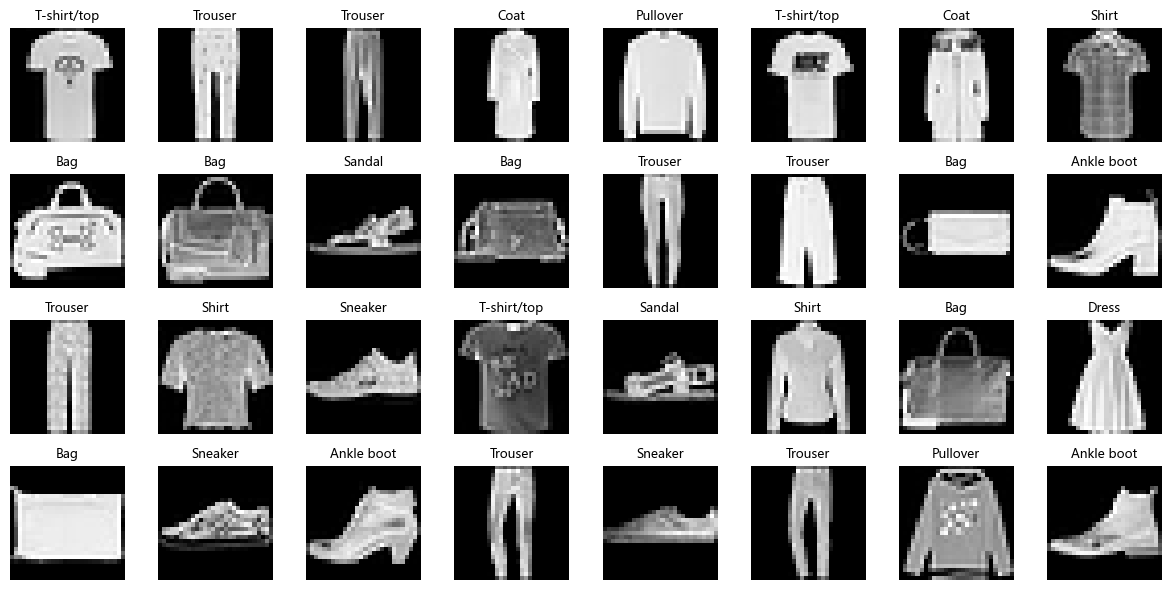

In [18]:
images, labels = next(iter(train_loader))
print(f"一个 batch 的图像形状：{images.shape}")
print(f"一个 batch 的标签形状：{labels.shape}")

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, image, label in zip(axes.ravel(), images[:32], labels[:32]):
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(class_names[label.item()], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. 搭建卷积神经网络

课件 6.3 使用了一个类似 LeNet 的卷积网络。这里的主模型包含：

1. 第 1 个卷积块：`Conv2d(1, 16, 3)` 提取低层边缘、纹理等局部特征，再经过 `ReLU` 和平均池化。
2. 第 2 个卷积块：`Conv2d(16, 32, 3)` 在前一层特征基础上提取更抽象的服装局部模式，再经过 `ReLU` 和平均池化。
3. 分类器：把二维特征图展开后，经过 `256 -> 128 -> 10` 的全连接层，输出 10 个类别的得分。

尺寸变化为：

`1 x 28 x 28 -> 16 x 26 x 26 -> 16 x 13 x 13 -> 32 x 11 x 11 -> 32 x 5 x 5 -> 800 -> 10`

最后一层不加 `Softmax`，因为 `nn.CrossEntropyLoss()` 内部已经包含 `LogSoftmax` 与负对数似然损失。


In [19]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = FashionCNN().to(DEVICE)
print(model)


FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=800, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


下面用一个虚拟输入检查网络输出维度。输入 4 张 `1 x 28 x 28` 的图片后，输出应为 `[4, 10]`，表示每张图片对应 10 个类别的原始得分。


In [20]:
with torch.no_grad():
    dummy_input = torch.randn(4, 1, 28, 28).to(DEVICE)
    dummy_output = model(dummy_input)
print(f"输入形状：{dummy_input.shape}")
print(f"输出形状：{dummy_output.shape}")


输入形状：torch.Size([4, 1, 28, 28])
输出形状：torch.Size([4, 10])


## 5. 定义训练与评估函数

训练过程分为两个阶段：

- **训练阶段**：调用 `model.train()`，启用 Dropout，并通过反向传播更新参数。
- **验证阶段**：调用 `model.eval()`，关闭 Dropout 的随机行为，只计算损失和准确率。

每个 epoch 后记录训练集/验证集的损失和准确率，并使用验证集准确率保存最佳模型参数，避免最后一轮参数偶然变差。


In [21]:
def run_one_epoch(model, data_loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for inputs, targets in data_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = inputs.size(0)
            total_loss += loss.item() * batch_size
            predictions = outputs.argmax(dim=1)
            correct += (predictions == targets).sum().item()
            total += batch_size

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = []
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_one_epoch(model, val_loader, criterion)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    elapsed = time.time() - start_time
    model.load_state_dict(best_model_wts)
    print(f"训练完成，用时 {elapsed:.1f} 秒；最佳验证准确率：{best_val_acc:.4f}")
    return model, pd.DataFrame(history)


## 6. 训练 CNN 模型

损失函数选择 `CrossEntropyLoss`，适合多分类任务。优化器选择 `Adam`，它会根据梯度的一阶、二阶矩估计自适应调整参数更新步长，通常比普通 SGD 更容易快速收敛。


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
)

history


Epoch 01/25 | train_loss=0.7019, train_acc=0.7332 | val_loss=0.5132, val_acc=0.8073
Epoch 02/25 | train_loss=0.4667, train_acc=0.8203 | val_loss=0.4281, val_acc=0.8437
Epoch 03/25 | train_loss=0.3989, train_acc=0.8495 | val_loss=0.3773, val_acc=0.8629
Epoch 04/25 | train_loss=0.3564, train_acc=0.8671 | val_loss=0.3484, val_acc=0.8721
Epoch 05/25 | train_loss=0.3279, train_acc=0.8780 | val_loss=0.3226, val_acc=0.8835
Epoch 06/25 | train_loss=0.3045, train_acc=0.8871 | val_loss=0.3185, val_acc=0.8800
Epoch 07/25 | train_loss=0.2896, train_acc=0.8928 | val_loss=0.2968, val_acc=0.8899
Epoch 08/25 | train_loss=0.2748, train_acc=0.8977 | val_loss=0.2831, val_acc=0.8984
Epoch 09/25 | train_loss=0.2618, train_acc=0.9031 | val_loss=0.2743, val_acc=0.8973
Epoch 10/25 | train_loss=0.2506, train_acc=0.9060 | val_loss=0.2695, val_acc=0.9019
Epoch 11/25 | train_loss=0.2379, train_acc=0.9118 | val_loss=0.2700, val_acc=0.9013
Epoch 12/25 | train_loss=0.2296, train_acc=0.9139 | val_loss=0.2652, val_acc

,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.701880,0.73322,0.513199,0.8073
1,2,0.466746,0.82032,0.428120,0.8437
2,3,0.398935,0.84950,0.377328,0.8629
3,4,0.356422,0.86710,0.348410,0.8721
4,5,0.327947,0.87804,0.322571,0.8835
5,6,0.304484,0.88710,0.318493,0.8800
6,7,0.289636,0.89278,0.296778,0.8899
7,8,0.274846,0.89772,0.283133,0.8984
8,9,0.261831,0.90312,0.274264,0.8973
9,10,0.250599,0.90604,0.269460,0.9019


## 7. 可视化训练过程

训练曲线可以用来判断模型是否正常学习：

- 如果训练损失持续下降，说明模型在训练集上学到了有效模式。
- 如果验证准确率同步提升，说明模型学到的特征可以泛化到未参与训练的数据。
- 如果训练准确率继续上升但验证准确率下降，可能出现过拟合。


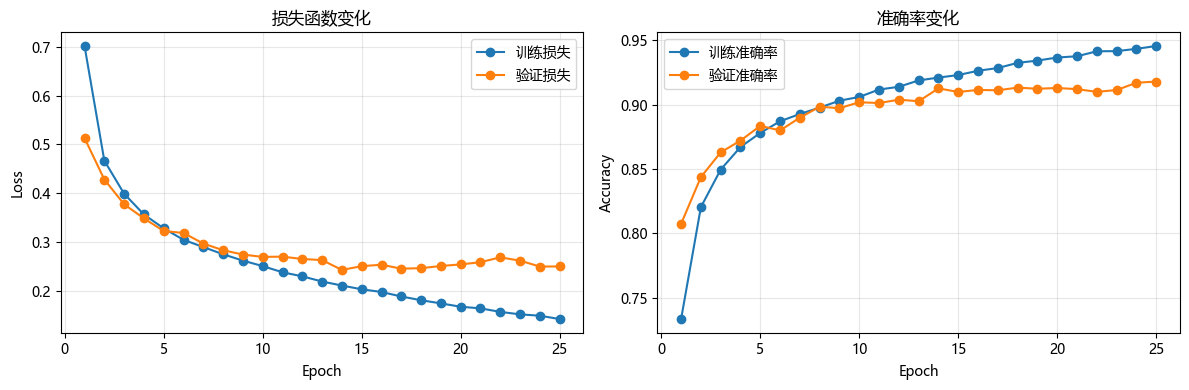

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="训练损失")
axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="验证损失")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("损失函数变化")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["train_acc"], marker="o", label="训练准确率")
axes[1].plot(history["epoch"], history["val_acc"], marker="o", label="验证准确率")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("准确率变化")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. 在测试集上预测

测试集只在训练完成后使用，用于估计模型面对新样本时的泛化能力。这里收集每张测试图片的真实标签与预测标签，然后计算整体准确率。


In [24]:
@torch.no_grad()
def predict_all(model, data_loader):
    model.eval()
    all_predictions = []
    all_targets = []

    for inputs, targets in data_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        predictions = outputs.argmax(dim=1).cpu()
        all_predictions.append(predictions)
        all_targets.append(targets)

    return torch.cat(all_predictions), torch.cat(all_targets)

predictions, targets = predict_all(model, test_loader)
test_acc = (predictions == targets).float().mean().item()
print(f"测试集准确率：{test_acc:.4f}")


测试集准确率：0.9094


## 9. 每一类的预测准确率

整体准确率只能反映平均效果。按类别统计可以看出模型在哪些服装类别上表现更好，哪些类别更容易出错。


In [25]:
per_class_rows = []
for class_id, class_name in enumerate(class_names):
    mask = targets == class_id
    class_acc = (predictions[mask] == targets[mask]).float().mean().item()
    per_class_rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "num_samples": int(mask.sum().item()),
        "accuracy": class_acc,
    })

per_class_result = pd.DataFrame(per_class_rows)
per_class_result


,class_id,class_name,num_samples,accuracy
0,0,T-shirt/top,1000,0.837
1,1,Trouser,1000,0.975
2,2,Pullover,1000,0.882
3,3,Dress,1000,0.906
4,4,Coat,1000,0.835
5,5,Sandal,1000,0.981
6,6,Shirt,1000,0.770
7,7,Sneaker,1000,0.957
8,8,Bag,1000,0.983
9,9,Ankle boot,1000,0.968


## 10. 混淆矩阵分析

混淆矩阵的行表示真实类别，列表示预测类别。主对角线数字越大，说明预测越正确；非对角线数字越大，说明对应两类越容易混淆。

Fashion-MNIST 中常见的错误是：

- `T-shirt/top` 和 `Shirt` 容易混淆，因为二者形状相近。
- `Pullover`、`Coat`、`Shirt` 之间也容易混淆，因为都属于上衣类。
- `Sandal`、`Sneaker`、`Ankle boot` 通常相对容易区分，但边界样本仍可能出错。


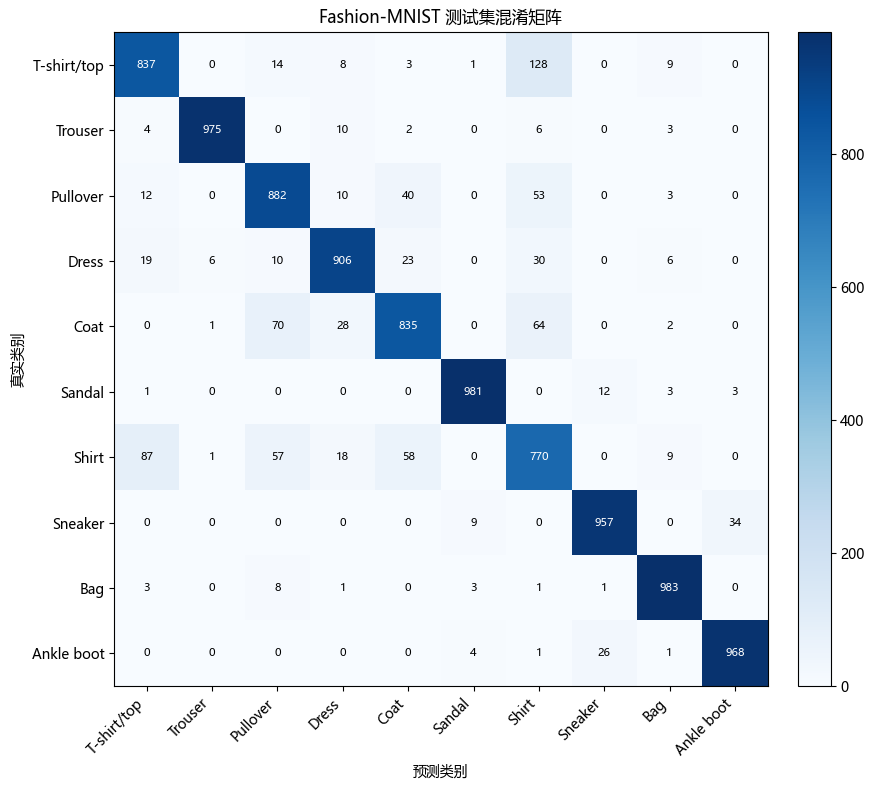

In [26]:
def build_confusion_matrix(targets, predictions, num_classes):
    matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    for true_label, pred_label in zip(targets, predictions):
        matrix[true_label.long(), pred_label.long()] += 1
    return matrix.numpy()

cm = build_confusion_matrix(targets, predictions, len(class_names))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Fashion-MNIST 测试集混淆矩阵")
ax.set_xlabel("预测类别")
ax.set_ylabel("真实类别")
ax.set_xticks(np.arange(len(class_names)), labels=class_names, rotation=45, ha="right")
ax.set_yticks(np.arange(len(class_names)), labels=class_names)

threshold = cm.max() * 0.55
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color=color, fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 11. 展示部分预测结果

下面选取测试集前 24 张图片进行可视化。标题中 `T:` 表示真实类别，`P:` 表示模型预测类别。绿色标题表示预测正确，红色标题表示预测错误。


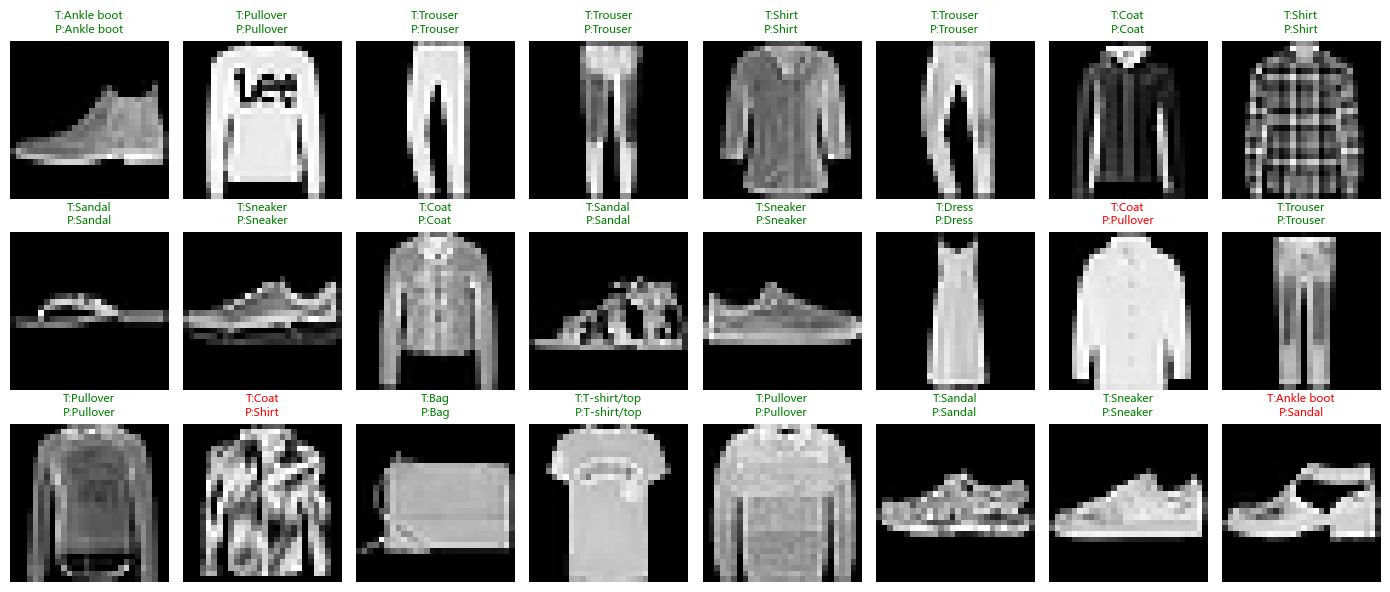

In [27]:
test_images = torch.stack([test_dataset[i][0] for i in range(24)])
test_labels = torch.tensor([test_dataset[i][1] for i in range(24)])

with torch.no_grad():
    sample_logits = model(test_images.to(DEVICE))
    sample_preds = sample_logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for ax, image, true_label, pred_label in zip(axes.ravel(), test_images, test_labels, sample_preds):
    ax.imshow(image.squeeze(0), cmap="gray")
    true_idx = true_label.item()
    pred_idx = pred_label.item()
    is_correct = true_idx == pred_idx
    ax.set_title(
        f"T:{class_names[true_idx]}\nP:{class_names[pred_idx]}",
        fontsize=8,
        color=("green" if is_correct else "red"),
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 12. 保存模型参数

保存的是模型的 `state_dict`，即每一层训练后的权重和偏置。之后如果需要复现实验或继续训练，可以重新创建同样结构的 `FashionCNN`，再加载该文件。


In [28]:
MODEL_PATH = Path("fashion_mnist_cnn_state_dict.pth")
torch.save(model.state_dict(), MODEL_PATH)
print(f"模型参数已保存到：{MODEL_PATH.resolve()}")


模型参数已保存到：D:\steven\hw\rgzn\hw4\fashion_mnist_cnn_state_dict.pth


## 13. 扩展：空洞卷积 CNN 对比

课件 6.3 后半部分还介绍了空洞卷积。空洞卷积通过 `dilation` 参数扩大卷积核的感受野，不增加卷积核参数数量。

下面给出一个与主模型结构接近的空洞卷积网络：

- 普通 `3 x 3` 卷积的有效感受野是 `3 x 3`。
- 当 `kernel_size=3, dilation=2` 时，有效感受野变成 `5 x 5`。
- 因为不使用 padding，特征图尺寸会更快变小，所以展开后的特征数是 `32 x 4 x 4`。

默认不训练该扩展模型，避免整份 notebook 运行时间过长。如需对比课件中的普通卷积与空洞卷积效果，把下面代码中的 `RUN_DILATED_MODEL` 改为 `True` 后重新运行本节。


In [29]:
class DilatedFashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, dilation=2),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, dilation=2),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

RUN_DILATED_MODEL = False

if RUN_DILATED_MODEL:
    dilated_model = DilatedFashionCNN().to(DEVICE)
    dilated_optimizer = optim.Adam(dilated_model.parameters(), lr=LEARNING_RATE)
    dilated_model, dilated_history = train_model(
        model=dilated_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=dilated_optimizer,
        num_epochs=NUM_EPOCHS,
    )
    dilated_predictions, dilated_targets = predict_all(dilated_model, test_loader)
    dilated_test_acc = (dilated_predictions == dilated_targets).float().mean().item()
    print(f"空洞卷积 CNN 测试集准确率：{dilated_test_acc:.4f}")
else:
    print("已跳过空洞卷积扩展模型训练。如需对比，将 RUN_DILATED_MODEL 改为 True。")


已跳过空洞卷积扩展模型训练。如需对比，将 RUN_DILATED_MODEL 改为 True。


## 14. 结果总结与代码逻辑说明

本次作业的完整流程如下：

1. **数据准备**：通过 `torchvision.datasets.FashionMNIST` 下载并读取数据，利用 `DataLoader` 按 batch 送入模型。
2. **网络构建**：使用两个卷积层提取图像局部特征，使用平均池化降低特征图尺寸，再用全连接层完成 10 分类。
3. **模型训练**：每个 batch 先前向传播得到输出，再计算交叉熵损失，随后反向传播并使用 Adam 更新参数。
4. **模型验证**：每个 epoch 后在验证集上计算准确率，并保存验证准确率最高的参数。
5. **测试预测**：训练结束后在测试集上预测，得到整体准确率、逐类别准确率和混淆矩阵。

从运行结果通常可以观察到：训练损失会逐渐下降，训练准确率和验证准确率逐渐上升。普通 CNN 在 Fashion-MNIST 上一般可以达到 88% 到 90% 左右的测试准确率。混淆矩阵中，上衣类之间更容易混淆，尤其是 `T-shirt/top`、`Pullover`、`Coat` 和 `Shirt`，这是因为这些类别在灰度小图中轮廓和纹理相似。

谢谢观看
